In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import cv2

def plot_graph_on_image(graph, image_path=None, image=None, draw_resistivity=True, higlight_nodes=None):
    """
    Plot the resistivity graph on top of the original image.
    
    Args:
        graph (nx.DiGraph): The resistivity graph.
        image_path (str): Path to the original image.
    """
    # Load the image
    if image_path:
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))
    elif image is None:
        raise Exception('Image is None')

    # Prepare node positions
    pos = {}
    for (node, node_type) in graph.nodes:
        pos[(node, node_type)] = (node[0], node[1])  # (x, y) format

    
    # Define a color mapping for nodes based on their main type.
    node_color_map = {
        'mainTrunk': 'red',
        'courson': 'blue',
        'cane': 'green',
        'lateralShoot': 'orange',
        'shoot': 'magenta',
        'rootCrown': 'black'
    }
    
    # Create a list of colors for nodes based on their type.
    node_colors = []
    for (node, node_type) in graph.nodes:
        # Use the first element of the node_type tuple to determine color.
        main_type = node_type[0]
        if node_type[1] == 'rootCrown':
            main_type = 'rootCrown'
        node_colors.append(node_color_map.get(main_type, 'gray'))
    
    # Prepare edge colors: assign color based on the parent's (target's) main type.
    edge_colors = []
    for (u, v) in graph.edges:
        parent_main_type = v[1][0]
        edge_colors.append(node_color_map.get(parent_main_type, 'gray'))
    
    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image, alpha=0.3)
    plt.axis("off")
    
    # Draw nodes
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=50,
        node_color=node_colors,
        alpha=0.9
    )

    if higlight_nodes is not None:
        if not isinstance(higlight_nodes, list):
            higlight_nodes = [higlight_nodes]
        # Highlight the specified node
        nx.draw_networkx_nodes(
            graph,
            pos,
            nodelist=higlight_nodes,
            node_size=200,
            node_color='yellow',
            alpha=0.9,
            node_shape='o',
            edgecolors='black', linewidths=2
        )

    
    # Draw edges with assigned colors
    nx.draw_networkx_edges(
        graph,
        pos,
        edge_color=edge_colors,
        alpha=0.7,
        arrows=True
    )

    if draw_resistivity:
        edge_labels = nx.get_edge_attributes(graph, "weight")
        formatted_labels = {edge: f"{weight:.2f}" for edge, weight in edge_labels.items()}
        nx.draw_networkx_edge_labels(
            graph,
            pos,
            edge_labels=formatted_labels,
            font_size=8,
            font_color="green",
        )

    # Show the plot
    # plt.title("Resistivity Graph Overlay on Original Image")
    plt.show()

Tree structure loaded successfully.
Example of tree structure ((x, y), (node_type, branch_type)):
((38, 67), ('lateralShoot', 'branchNode'))
<class 'tuple'>
((43, 82), ('lateralShoot', 'branchNode'))
<class 'tuple'>


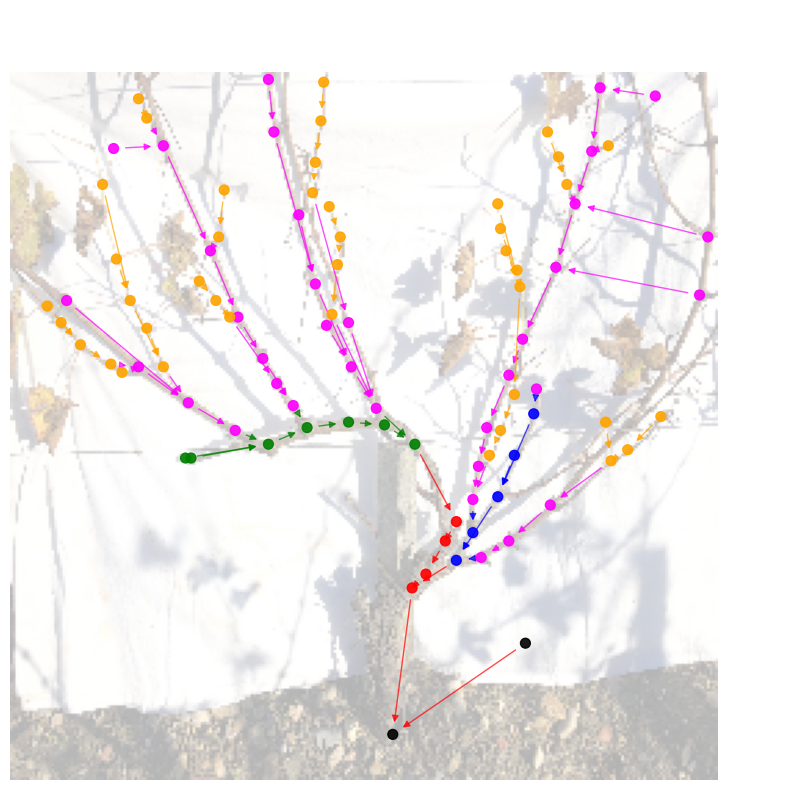

<class 'networkx.classes.reportviews.NodeView'>
Predecessors of node  ((185, 96), ('shoot', 'branchNode'))
((197, 70), ('shoot', 'branchNode'))


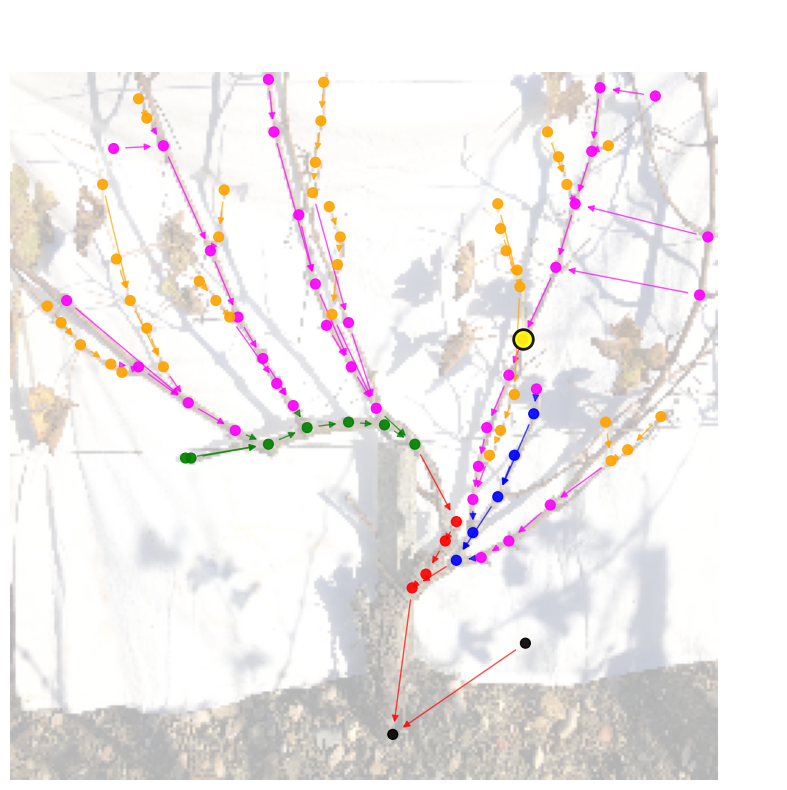

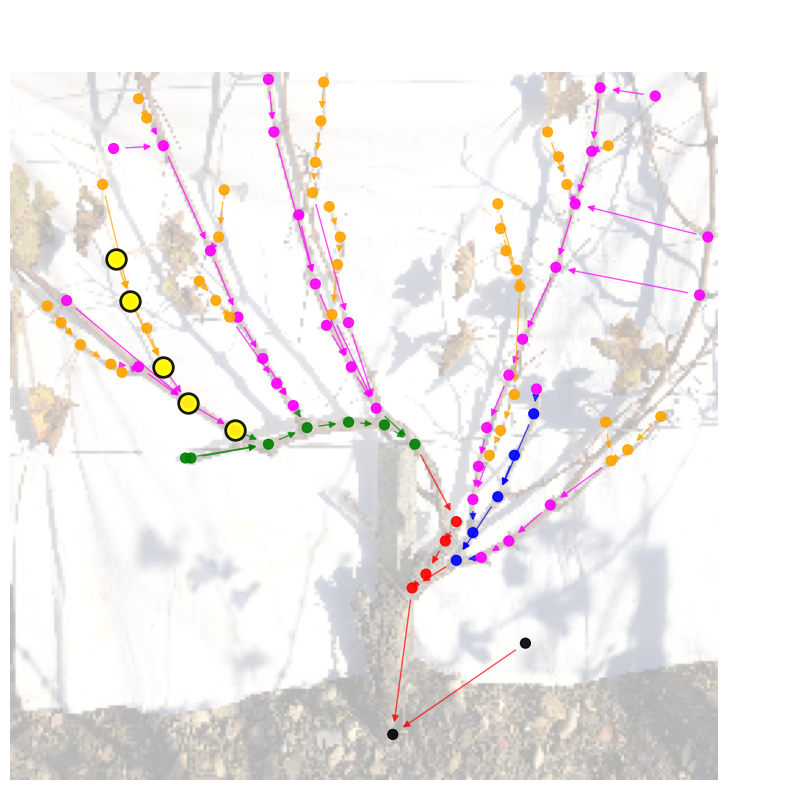

In [2]:
import networkx as nx
import ast

tree_structure = nx.read_adjlist("tree_structure.adjlist", create_using=nx.DiGraph, delimiter=";")
print("Tree structure loaded successfully.")

# Convert string node labels to tuple using ast.literal_eval for tree_structure
tree_structure = nx.relabel_nodes(tree_structure, ast.literal_eval)

print("Example of tree structure ((x, y), (node_type, branch_type)):")
for i, node in enumerate(tree_structure.nodes()):
    print(node)
    print(type(node))
    if i == 1:  # Print only the first 5 nodes
        break

plot_graph_on_image(
    tree_structure,
    image_path="/media/hdd/VinProDatasets/3D2cut_Single_Guyot/02-IndependentTestSet/Set00_IMG_3299.jpeg",
    draw_resistivity=False
)

print(type(tree_structure.nodes))
nodes = list(tree_structure.nodes)
node = nodes[20]

print("Predecessors of node ", node)
for pred in tree_structure.predecessors(node):
    print(pred)

plot_graph_on_image(
    tree_structure,
    image_path="/media/hdd/VinProDatasets/3D2cut_Single_Guyot/02-IndependentTestSet/Set00_IMG_3299.jpeg",
    draw_resistivity=False,
    higlight_nodes=node
)

plot_graph_on_image(
    tree_structure,
    image_path="/media/hdd/VinProDatasets/3D2cut_Single_Guyot/02-IndependentTestSet/Set00_IMG_3299.jpeg",
    draw_resistivity=False,
    higlight_nodes=nodes[0:5]
)